<a href="https://colab.research.google.com/github/snig-17/QM-GRUNGE/blob/main/Factors/Member_Hired_Ratio_Alice.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Factor: Member to Hired Ratio

On each expedition there are a different number of hired 'Sherpas' and paid climbers - this variable measures the ratio of member:hired climbers to see if this affects success of expedition.

In [1]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import plotly
import plotly.express as px
import warnings
import re

warnings.filterwarnings('ignore')
sns.set(font_scale=1.5)
sns.set_style("white")
plt.rcParams['figure.figsize'] = (12, 8)


In [2]:
from google.colab import files
uploaded = files.upload()


filename = list(uploaded.keys())[0]
df = pd.read_csv(filename)


Saving expeditions5.csv to expeditions5.csv


In [12]:
from google.colab import files
uploaded2 = files.upload()


filename2 = list(uploaded2.keys())[0]
other_df = pd.read_csv(filename2)

Saving expeditions7.csv to expeditions7.csv


In [3]:
df.head()

,Yr/Seas,Host,Nationalities,Leader(s),Route(s),Result,Smtrs,Dead,ExpedID,Year,...,hired_DR,mbr_DR,mbr_hired_ratio,total_DR,clean_routes,route_codes,result_clean,result_code,grp_success,success_rate
0,1991 Spr,China,"USA, New Zealand",Robert Anderson,A couloir just W of N Col-N Ridge,Bad Conditions,0.0,NaN,EVER-911-09,1991,...,0.0,0.0,0.0,0.0,a couloir just w of n col-n ridge,6,bad conditions,6,0,0
1,1994 Spr,China,"New Zealand, Canada, France, Guatemala, Romani...",Russell Brice,Couloir on E side of N Ridge (to 8000m) / N Co...,Route Difficulty,0.0,NaN,EVER-941-13,1994,...,0.0,0.0,0.4,0.0,couloir on e side of n ridge,6,route difficulty,3,0,0
2,1999 Aut,China,S Korea,Kim Won-Mo,E Face,Bad Weather,0.0,NaN,EVER-993-04,1999,...,0.0,0.0,0.0,0.0,e face,6,bad weather,6,0,0
3,2001 Aut,China,Hungary,David Klein,E Face,Bad Conditions,0.0,NaN,EVER-013-02,2001,...,0.0,0.0,0.0,0.0,e face,6,bad conditions,6,0,0
4,1994 Spr,China,"USA, Canada",David Breashears,E Face-S Col (Venables rte),Bad Conditions,0.0,NaN,EVER-941-05,1994,...,0.0,0.0,0.0,0.0,e face-s col,6,bad conditions,6,0,0


In [17]:
# Make sure the data is clean and seen by python as numerical
df['mbr_hired_ratio'] = pd.to_numeric(df['mbr_hired_ratio'], errors='coerce').fillna(0)
df['mbr_hired_ratio'] = df['mbr_hired_ratio'].where(df['mbr_hired_ratio'] >= 0)

First, we look at member:hired ratio over time!

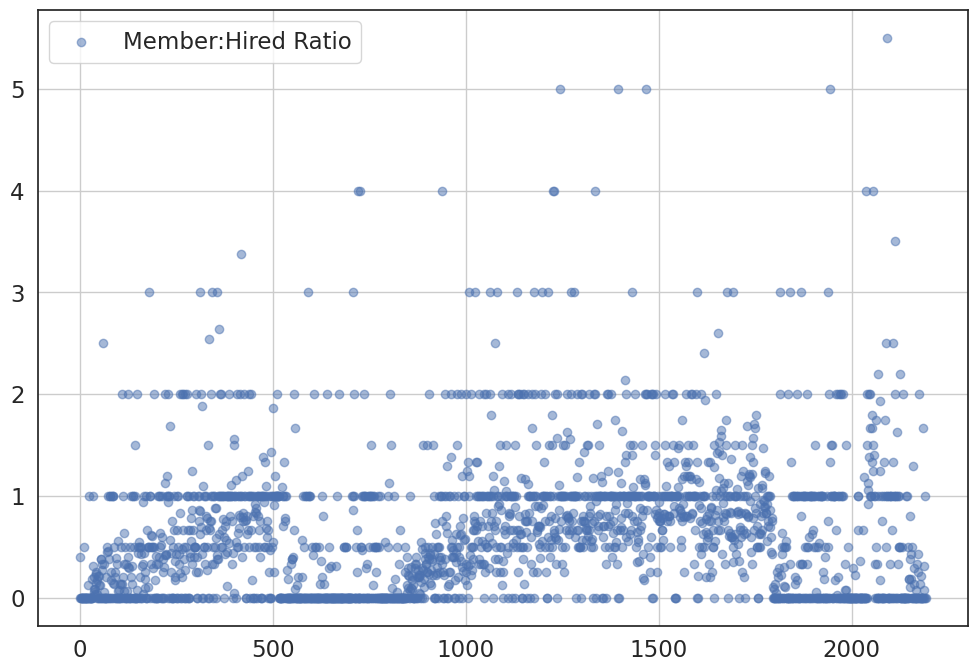

In [19]:
df = df.sort_values(by='Year', ascending=True)
plt.scatter(df.index, df['mbr_hired_ratio'], label='Member:Hired Ratio', alpha=0.5)
plt.legend()
plt.grid()
plt.show()

The dataframe is already sorted by time - this scattergraph does not show us very much however. There may be scientific expeditions which do not hire sherpas to help with the climb.

There are some expeditions with only sherpas - for example one in 2021 (EVER-211-01) for rope fixing - these show up as 0 mbr:hired ratio. There are 11 Sherpa Rope-fixing expeditions in this dataset - so we can remove these easily.

In [20]:
df2 = df[~df['Leader(s)'].astype(str).str.contains('Sherpa Rope-Fixing', case=False, na=False)]
df2.shape

(2181, 26)

In [6]:
print(df2['mbr_hired_ratio'].describe())

count    2181.000000
mean        0.666263
std         0.683370
min         0.000000
25%         0.000000
50%         0.560000
75%         1.000000
max         5.500000
Name: mbr_hired_ratio, dtype: float64


In [7]:
print((df2['mbr_hired_ratio'] == 0).sum())

581


So 581/2181 (26%) expeditions still have member:hired ratios of 0, and there is no clear way to filter out scientific/research expeditions.

Maybe a quarter of people do just climb without a sherpa? But it could also be a problem with the data. This is a problem to be aware of.

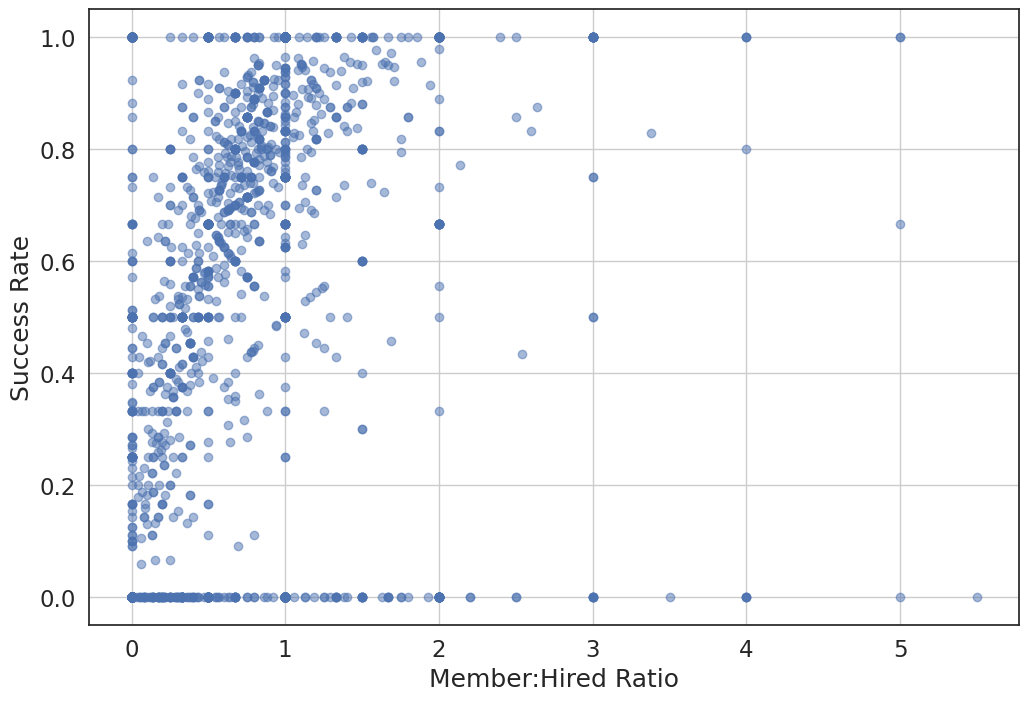

In [15]:
#Let's carry on as if it's not a problem!
df2['success_rate']=pd.to_numeric(df2['success_rate'], errors='coerce')
df2['success_rate'] = df2['success_rate'].clip(upper=1)

plt.scatter(df2['mbr_hired_ratio'], df2['success_rate'], alpha=0.5)
plt.xlabel('Member:Hired Ratio')
plt.ylabel('Success Rate')
plt.grid()
plt.show()

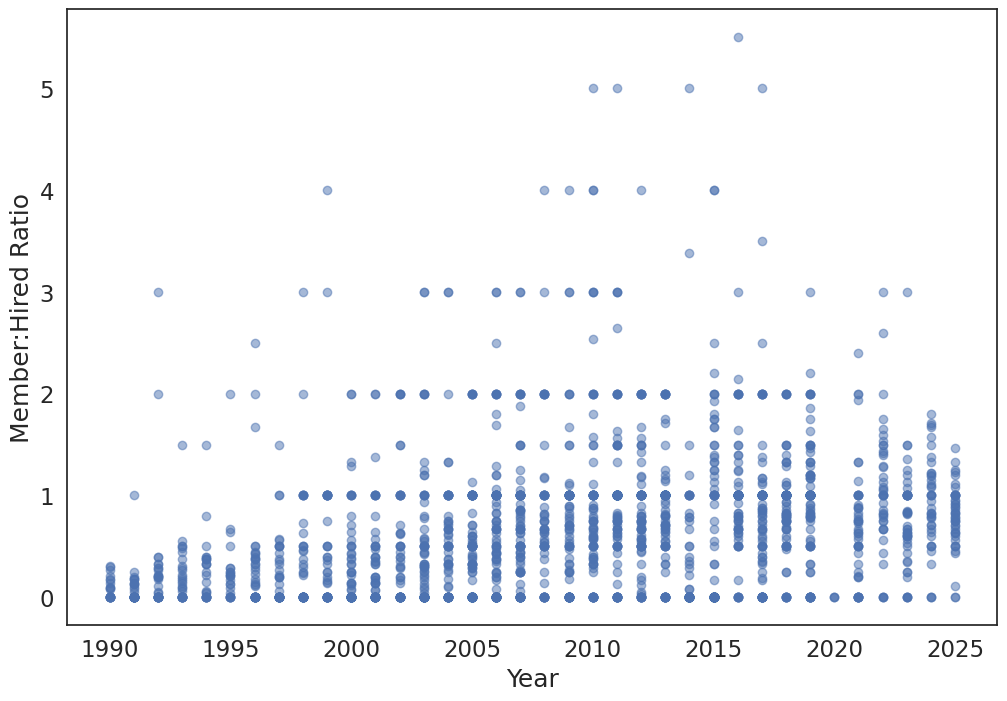

In [11]:
plt.scatter(df2['Year'], df2['mbr_hired_ratio'], alpha=0.5)
plt.xlabel('Year')
plt.ylabel('Member:Hired Ratio')
plt.show()

Doing all the same again but with a new mbr:hired ratio column - this time hired count comes from the higher of either the difference between group size and member count, or the Hired AdvBC value - both from Himalayan database of course!

In [14]:
other_df['mbr_hired_ratio2'] = pd.to_numeric(other_df['mbr_hired_ratio2'], errors='coerce').fillna(0)
other_df['mbr_hired_ratio2'] = other_df['mbr_hired_ratio2'].where(other_df['mbr_hired_ratio2'] >= 0)

In [22]:
other_df2 = other_df[~other_df['Leader(s)'].astype(str).str.contains('Sherpa Rope-Fixing', case=False, na=False)]

print((other_df2['mbr_hired_ratio'] == 0).sum())

581


Never mind! That was entirely worthless!

There are the same number of expeditions with 0!


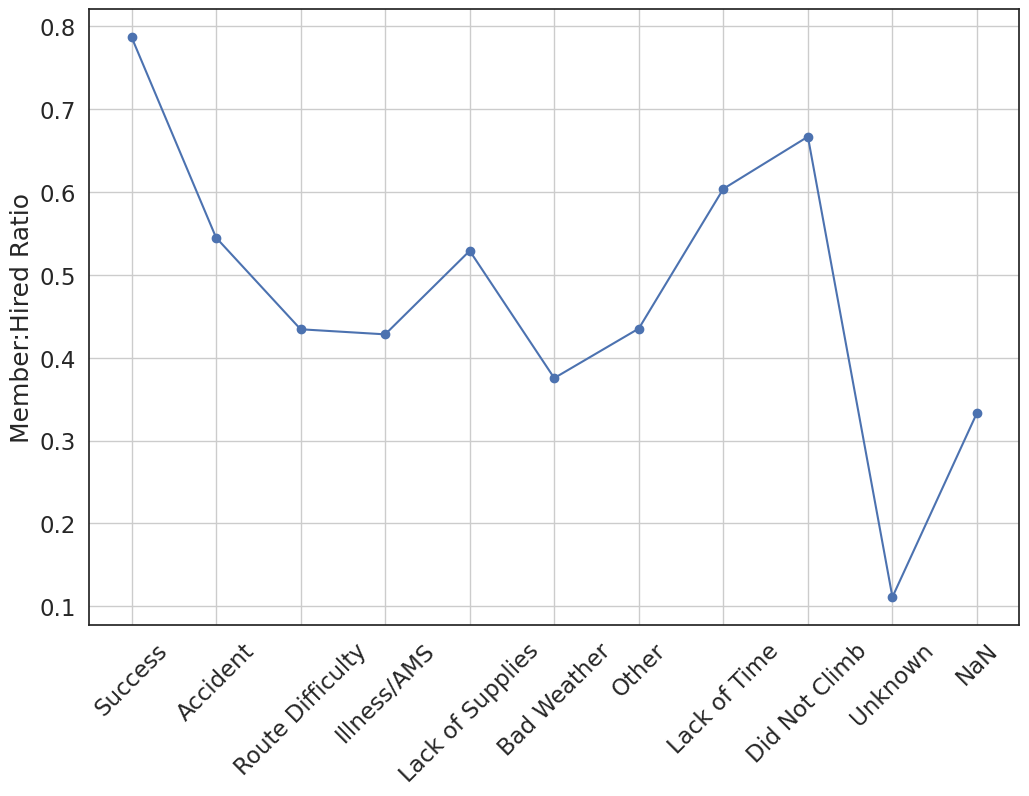

In [29]:
grouped_result = df2.groupby('result_code')['mbr_hired_ratio'].mean()
plt.plot(grouped_result.index, grouped_result, marker='o')
plt.xlabel('')
plt.xticks(ticks=[1,2,3,4,5,6,7,8,9,10,11],labels = ['Success', 'Accident', 'Route Difficulty', 'Illness/AMS', 'Lack of Supplies', 'Bad Weather', 'Other', 'Lack of Time', 'Did Not Climb', 'Unknown', 'NaN'],rotation=45)
plt.ylabel('Member:Hired Ratio')
plt.grid()
plt.show()

What a cool graph?
SUccessful missions have the highest ratio, but also did not climb ...